In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# ----------------------------
# 1. Création d'un faux marché
# ----------------------------

n = 300

drift = 0.0005          # tendance moyenne positive : +0.05% par jour
volatility = 0.01      # volatilité quotidienne

returns_real = np.random.normal(loc=drift, scale=volatility, size=n)

price = 100 * np.exp(np.cumsum(returns_real))

df = pd.DataFrame({
    "price_real": price,
    "return_real": returns_real
})

# ----------------------------
# 2. Detrending des rendements
# ----------------------------

average_log_return = df["return_real"].mean()

df["return_detrended"] = df["return_real"] - average_log_return

# Reconstruction d'un prix detrendé uniquement pour visualisation
df["price_detrended_visual"] = 100 * np.exp(np.cumsum(df["return_detrended"]))

# ----------------------------
# 3. Exemple de stratégie
# ----------------------------

# Stratégie volontairement naïve :
# Signal = toujours long
df["signal"] = 1

df["pnl_real"] = df["signal"] * df["return_real"]
df["pnl_detrended"] = df["signal"] * df["return_detrended"]

df["equity_real"] = 100 * np.exp(np.cumsum(df["pnl_real"]))
df["equity_detrended"] = 100 * np.exp(np.cumsum(df["pnl_detrended"]))

print("Rendement moyen réel :", df["return_real"].mean())
print("Rendement moyen detrendé :", df["return_detrended"].mean())

print("Performance finale réelle :", df["equity_real"].iloc[-1])
print("Performance finale detrendée :", df["equity_detrended"].iloc[-1])

Rendement moyen réel : 0.000444514409187595
Rendement moyen detrendé : 1.8503717077085944e-19
Performance finale réelle : 114.26547952087998
Performance finale detrendée : 100.0


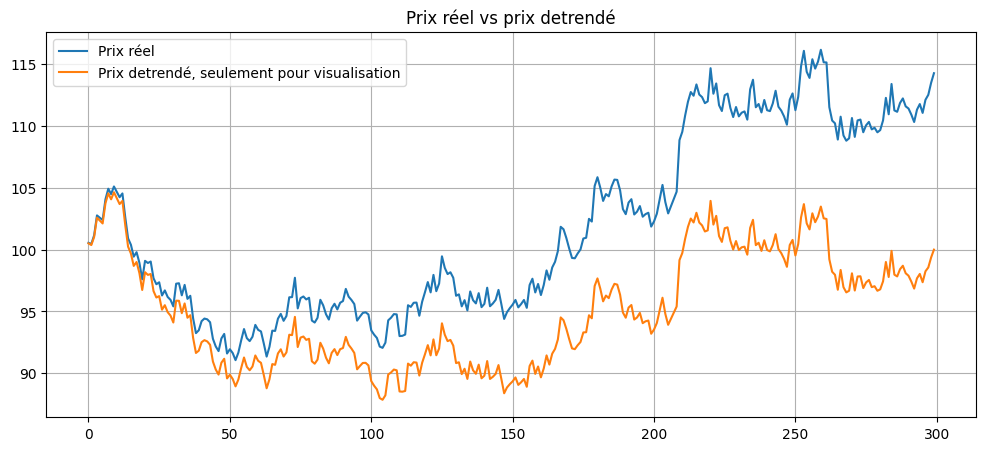

In [2]:
plt.figure(figsize=(12, 5))
plt.plot(df["price_real"], label="Prix réel")
plt.plot(df["price_detrended_visual"], label="Prix detrendé, seulement pour visualisation")
plt.title("Prix réel vs prix detrendé")
plt.legend()
plt.grid(True)
plt.show()

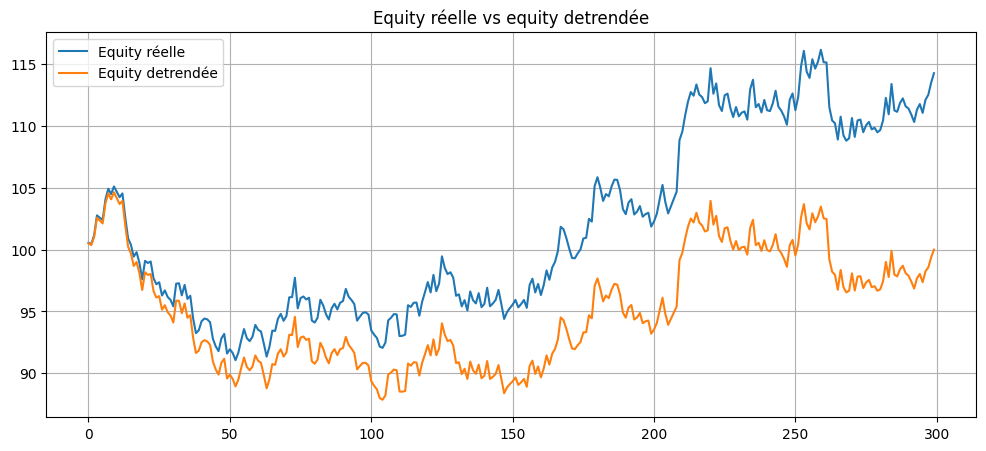

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(df["equity_real"], label="Equity réelle")
plt.plot(df["equity_detrended"], label="Equity detrendée")
plt.title("Equity réelle vs equity detrendée")
plt.legend()
plt.grid(True)
plt.show()

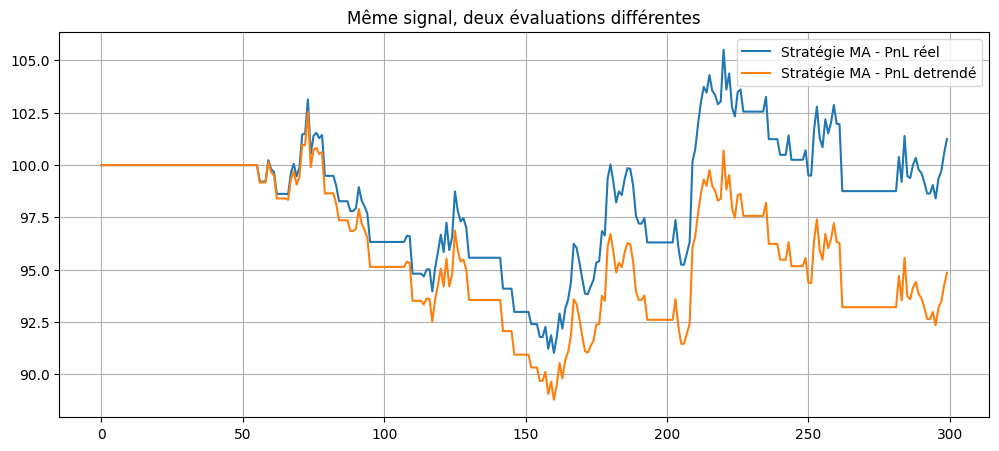

In [4]:
# Moyenne mobile sur le prix réel
df["ma_20"] = df["price_real"].rolling(20).mean()

# Signal généré avec les prix réels
df["signal_ma"] = np.where(df["price_real"] > df["ma_20"], 1, 0)

# Décalage du signal pour éviter le lookahead bias
df["signal_ma"] = df["signal_ma"].shift(1)

# Calcul des performances
df["pnl_ma_real"] = df["signal_ma"] * df["return_real"]
df["pnl_ma_detrended"] = df["signal_ma"] * df["return_detrended"]

df["equity_ma_real"] = 100 * np.exp(np.nancumsum(df["pnl_ma_real"]))
df["equity_ma_detrended"] = 100 * np.exp(np.nancumsum(df["pnl_ma_detrended"]))

plt.figure(figsize=(12, 5))
plt.plot(df["equity_ma_real"], label="Stratégie MA - PnL réel")
plt.plot(df["equity_ma_detrended"], label="Stratégie MA - PnL detrendé")
plt.title("Même signal, deux évaluations différentes")
plt.legend()
plt.grid(True)
plt.show()